# **Step I: Import Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# **Step II: Define sample dataset/Download dataset**

In [ ]:
# 1. Define 10 sample points (2D features: x1, x2)
# The first 5 points belong to Class 0, the next 5 belong to Class 1
X = np.array([
    [1.0, 1.5], [1.2, 2.5], [2.0, 1.0], [2.5, 2.0], [3.0, 1.2], # Class 0 (y = 0)
    [4.5, 5.0], [5.0, 4.2], [5.5, 5.5], [6.0, 4.0], [6.5, 6.0]  # Class 1 (y = 1)
])

# Define the corresponding labels
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [ ]:
for i in range(len(X)):
    print(X[i], y[i])

[1.  1.5] 0
[1.2 2.5] 0
[2. 1.] 0
[2.5 2. ] 0
[3.  1.2] 0
[4.5 5. ] 1
[5.  4.2] 1
[5.5 5.5] 1
[6. 4.] 1
[6.5 6. ] 1


# **Step III:  Initialize and train the Logistic Regression model**

Option A: Using sklearn LogisticRegression()

In [ ]:
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

Option B: Using custom LogisticRegression()

In [ ]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=10000):
        """
        Initializes the logistic regression model.
        """
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None # This will store β1, β2, ..., βd
        self.bias = None    # This will store β0

    def _sigmoid(self, z):
        """
        The sigmoid activation function.
        Squashes continuous values into a 0 to 1 probability range.
        """
        # np.clip prevents overflow errors in np.exp() if z gets too largely negative
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        """
        Trains the model using Gradient Descent to find the optimal separating hyperplane.
        """
        num_samples, num_features = X.shape

        # 1. Initialize weights (β1, β2) and bias (β0) to zero
        self.weights = np.zeros(num_features)
        self.bias = 0

        # 2. Gradient Descent Loop
        for _ in range(self.num_iterations):

            # Calculate linear combination: z = X*w + b
            linear_model = np.dot(X, self.weights) + self.bias

            # Apply sigmoid to get probabilities: ŷ = 1 / (1 + e^(-z))
            y_predicted = self._sigmoid(linear_model)

            # Calculate gradients (derivatives of the loss function)
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):
        """
        Returns the probability of the positive class (Class 1).
        """
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        """
        Predicts class labels based on a probability threshold (default 0.5).
        """
        probabilities = self.predict_proba(X)
        # If probability > threshold, predict 1, else predict 0
        return np.array([1 if p >= threshold else 0 for p in probabilities])


In [ ]:
if __name__ == "__main__":
    # Initialize and train
    # Note: We use a higher learning rate and iterations for this specific tiny dataset
    # so gradient descent converges nicely.
    clf = CustomLogisticRegression(learning_rate=0.1, num_iterations=1000)
    clf.fit(X, y)

    print("Custom Model Trained!")
    print(f"Intercept (β0): {clf.bias:.4f}")
    print(f"Coefficients (β1, β2): {clf.weights[0]:.4f}, {clf.weights[1]:.4f}")
    print("-" * 40)

    # Test predictions
    new_samples = np.array([[3.5, 3.5], [1.0, 1.0], [6.0, 6.0]])
    predictions = clf.predict(new_samples)
    probs = clf.predict_proba(new_samples)

    for i, sample in enumerate(new_samples):
        print(f"Sample {sample} -> P(y=1): {probs[i]:.4f} | Predicted Class: {predictions[i]}")

Custom Model Trained!
Intercept (β0): -5.9187
Coefficients (β1, β2): 0.7606, 1.1187
----------------------------------------
Sample [3.5 3.5] -> P(y=1): 0.6590 | Predicted Class: 1
Sample [1. 1.] -> P(y=1): 0.0173 | Predicted Class: 0
Sample [6. 6.] -> P(y=1): 0.9953 | Predicted Class: 1


# **Step IV: Retrieve the separating hyperplane parameters**

In [ ]:
# This matches the β0 (intercept) and β1, β2 (coefficients) from your slides
beta_0 = model.intercept_[0]
beta_1, beta_2 = model.coef_[0]

In [ ]:
print("Model trained successfully!")
print(f"Intercept (β0): {beta_0:.4f}")
print(f"Coefficients (β1, β2): {beta_1:.4f}, {beta_2:.4f}")
print(f"Decision Boundary Equation: {beta_0:.4f} + {beta_1:.4f}*x1 + {beta_2:.4f}*x2 = 0\n")

Model trained successfully!
Intercept (β0): -6.0386
Coefficients (β1, β2): 0.8823, 0.8681
Decision Boundary Equation: -6.0386 + 0.8823*x1 + 0.8681*x2 = 0



# **Step V: Predict a new sample**

In [ ]:
new_sample = np.array([[3.5, 3.5]])
prediction = model.predict(new_sample)
probability = model.predict_proba(new_sample)

print(f"Prediction for point {new_sample[0]}: Class {prediction[0]}")
print(f"Probability [Class 0, Class 1]: {probability[0]}")

Prediction for point [3.5 3.5]: Class 1
Probability [Class 0, Class 1]: [0.47805717 0.52194283]


# **Step VI: Plotting the data and the decision boundary (Optional)**

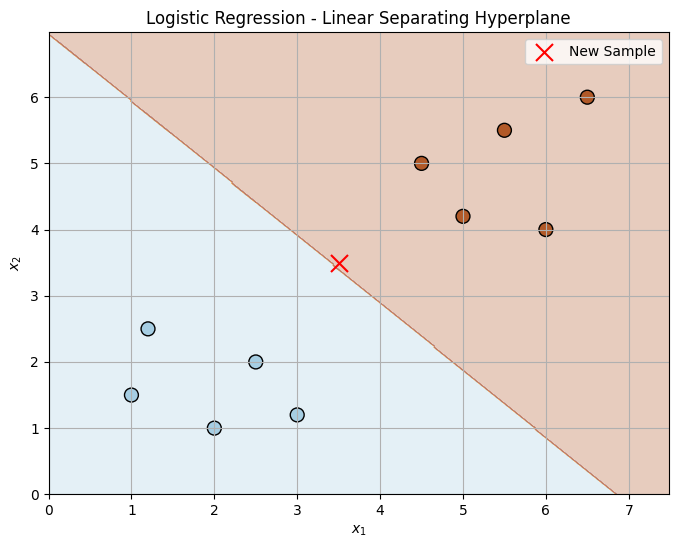

In [ ]:
# Create a grid to evaluate the model
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict across the grid to create the boundary line
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired) # Draw the decision regions
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.Paired)
plt.scatter(new_sample[:, 0], new_sample[:, 1], c='red', marker='x', s=150, label='New Sample')

plt.title('Logistic Regression - Linear Separating Hyperplane')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)
plt.show()